# Exploració de les dades — MSFT (Microsoft)

L'objectiu d'aquest notebook és entendre **quines dades tenim**, com estan estructurades i si hi ha alguna cosa a tenir en compte abans de modelar.

---

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

posicio = 1978883 % 10
tickers_list = ["NVDA", "AAPL", "GOOG", "MSFT", "AMZN",
                "META", "AVGO", "ORCL", "TSM", "SAP"]
ticker_name = tickers_list[posicio]
ticker = yf.Ticker(ticker_name)

df = ticker.history(period="10y")
df.index = df.index.tz_localize(None)  # elimina timezone per comoditat

print(f"Ticker assignat: {ticker_name}")

Ticker assignat: MSFT


## 1. Estructura bàsica del dataset

In [2]:
print(f"Dimensions:       {df.shape[0]} files x {df.shape[1]} columnes")
print(f"Data inici:       {df.index.min().date()}")
print(f"Data fi:          {df.index.max().date()}")
print(f"Anys coberts:     {(df.index.max() - df.index.min()).days / 365:.1f}")
print(f"Freqüència:       diària (dies de mercat, sense caps de setmana ni festius)")
print()
print("Columnes:")
for col in df.columns:
    print(f"  - {col}")

Dimensions:       2514 files x 7 columnes
Data inici:       2016-04-13
Data fi:          2026-04-13
Anys coberts:     10.0
Freqüència:       diària (dies de mercat, sense caps de setmana ni festius)

Columnes:
  - Open
  - High
  - Low
  - Close
  - Volume
  - Dividends
  - Stock Splits


## 2. Descripció de cada columna

| Columna | Descripció |
|---|---|
| **Open** | Preu al qual va obrir la sessió borsària |
| **High** | Preu màxim assolit durant la sessió |
| **Low** | Preu mínim assolit durant la sessió |
| **Close** | Preu de tancament al final de la sessió — **variable objectiu** |
| **Volume** | Nombre d'accions negociades durant la sessió |
| **Dividends** | Import del dividend pagat aquell dia (0 la majoria de dies) |
| **Stock Splits** | Factor d'split aplicat aquell dia (0 si no n'hi ha hagut cap) |

## 3. Estadístiques descriptives

In [3]:
df[["Open", "High", "Low", "Close", "Volume"]].describe().round(2)

,Open,High,Low,Close,Volume
count,2514.00,2514.00,2514.00,2514.00,2.514000e+03
mean,232.33,234.48,230.03,232.35,2.745660e+07
std,139.88,140.99,138.60,139.82,1.237508e+07
min,43.35,43.55,42.57,42.91,5.855900e+06
25%,99.41,100.29,98.27,99.39,1.965305e+07
50%,227.87,230.91,225.03,227.79,2.433555e+07
75%,332.37,335.10,329.40,331.67,3.143358e+07
max,552.02,552.24,538.53,539.83,1.335030e+08


## 4. Qualitat de les dades

In [4]:
print("Valors nuls per columna:")
print(df.isnull().sum())
print()

# Dies sense sessió (caps de setmana i festius) — normal que no hi siguin
total_dies = (df.index.max() - df.index.min()).days
dies_mercat = len(df)
print(f"Dies totals en el període:  {total_dies}")
print(f"Dies de mercat amb dades:   {dies_mercat}")
print(f"Dies sense dades (caps set. + festius): {total_dies - dies_mercat}")

Valors nuls per columna:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Dies totals en el període:  3652
Dies de mercat amb dades:   2514
Dies sense dades (caps set. + festius): 1138


### Dividends

Un **dividend** és un pagament en efectiu que l'empresa fa als seus accionistes, normalment de forma trimestral. És una manera de repartir part dels beneficis.

Per exemple, si Microsoft paga un dividend de 0.75\$, vol dir que per cada acció que tinguis reps 0.75\$ en efectiu aquell dia.

En el dataset apareix com una columna amb valor 0 tots els dies excepte els dies concrets en què es paga el dividend. És útil com a **variable d'intervenció** (dummy) en models estadístics, ja que el pagament de dividends pot afectar el preu de l'acció.

In [5]:
dividends = df[df["Dividends"] > 0][["Dividends"]]
print(f"Nombre de pagaments de dividend: {len(dividends)}")
if len(dividends) > 0:
    print(f"Import mínim: {dividends['Dividends'].min():.4f}$")
    print(f"Import màxim: {dividends['Dividends'].max():.4f}$")
    print()
    print("Últims 5 dividends:")
    print(dividends.tail())

Nombre de pagaments de dividend: 40
Import mínim: 0.3600$
Import màxim: 0.9100$

Últims 5 dividends:
            Dividends
Date                 
2025-02-20       0.83
2025-05-15       0.83
2025-08-21       0.83
2025-11-20       0.91
2026-02-19       0.91


### Stock Splits

Un **stock split** és quan l'empresa divideix cada acció existent en múltiples accions noves. Per exemple, un split 2:1 converteix cada acció en 2 accions, però el preu de cada una queda a la meitat.

El valor total de la inversió **no canvia**, però el preu per acció sí. Això provoca un **trencament estructural brusc** a la sèrie de preus: el dia del split el preu sembla caure a la meitat, però no és una pèrdua real.

yfinance ja **ajusta els preus histèrics** perquè siguin comparables (els preus anteriors al split es divideixen pel factor), de manera que no hauríem de veure salts artificials a la sèrie.

In [6]:
splits = df[df["Stock Splits"] > 0][["Stock Splits"]]
if len(splits) > 0:
    print(f"Stock splits detectats: {len(splits)}")
    print(splits)
else:
    print("No hi ha hagut cap stock split en el període.")

No hi ha hagut cap stock split en el període.


## 5. Visualització de les columnes de preu

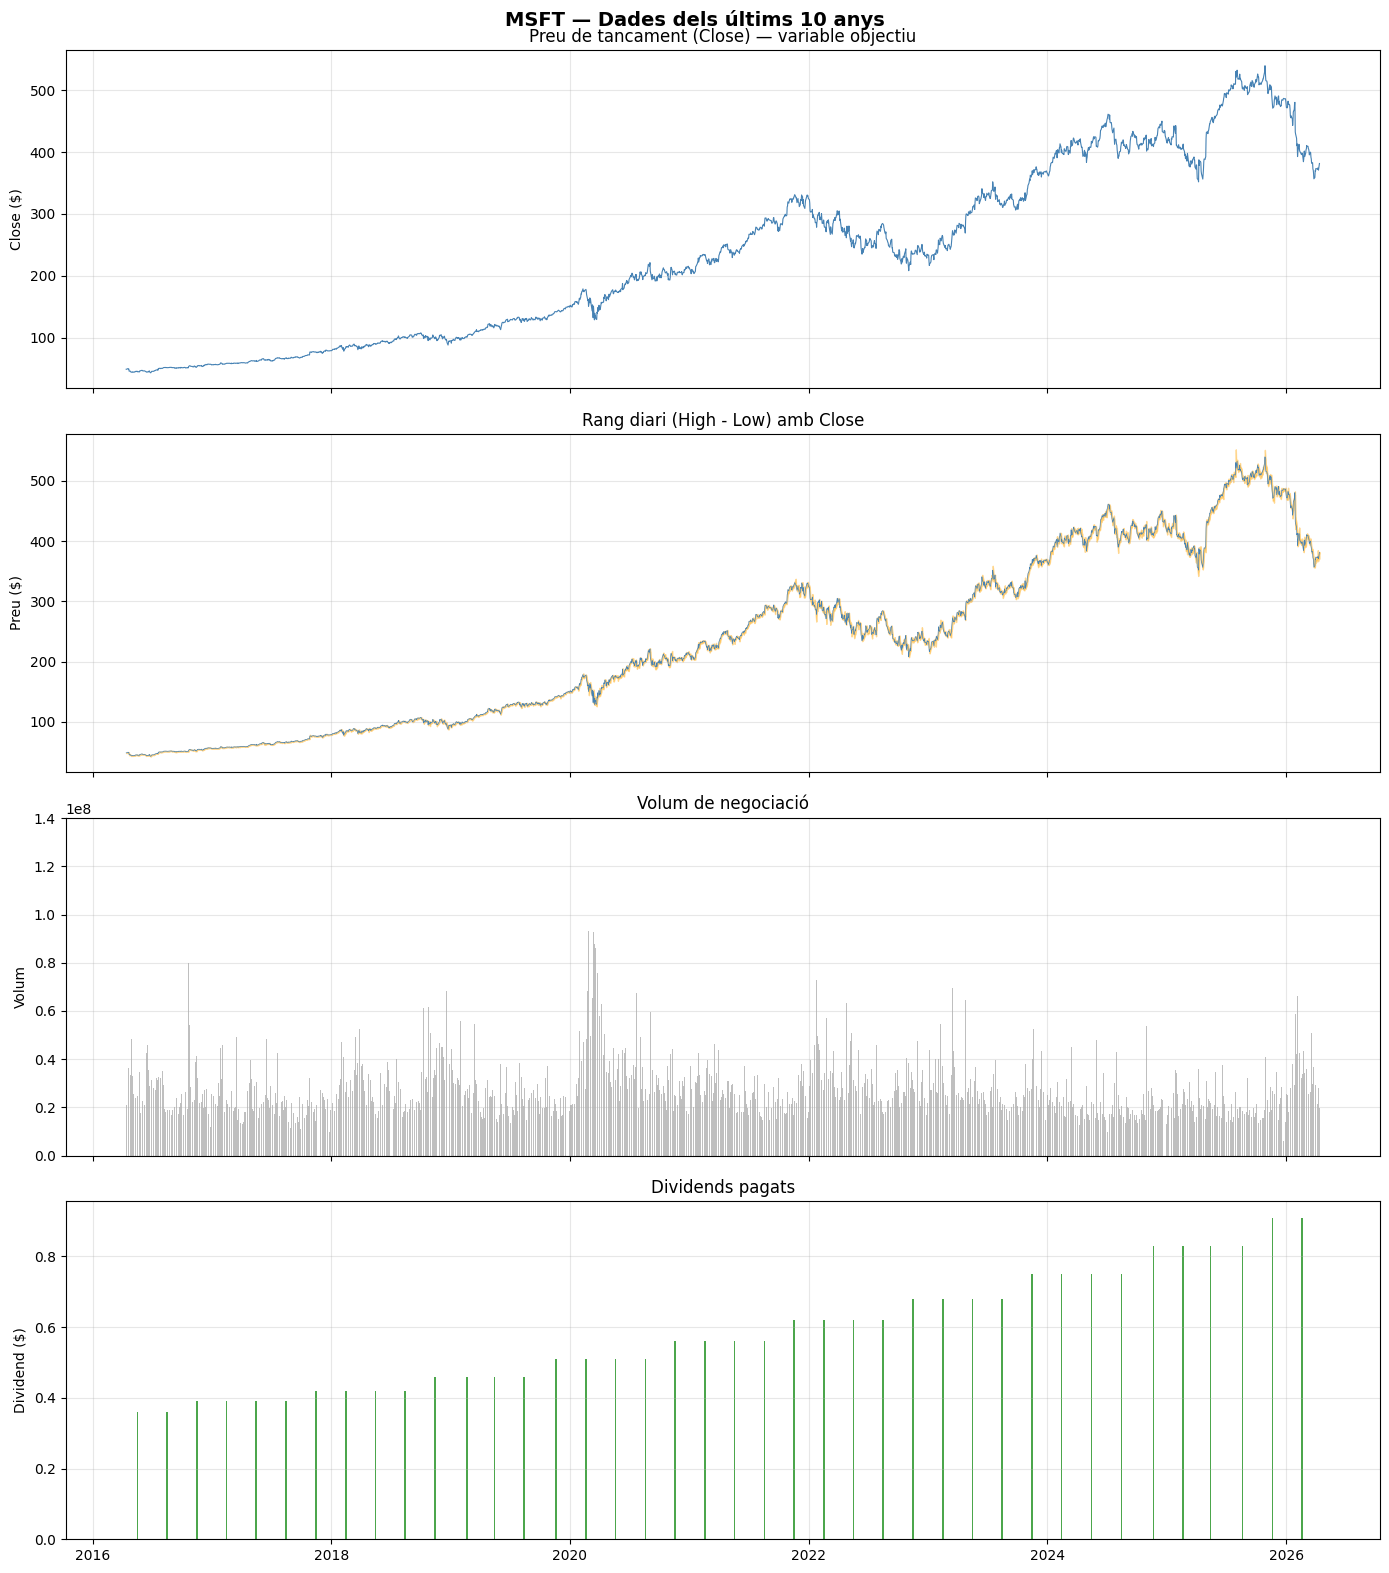

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.suptitle(f"{ticker_name} — Dades dels últims 10 anys", fontsize=14, fontweight="bold")

# Close
axes[0].plot(df.index, df["Close"], color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Close ($)")
axes[0].set_title("Preu de tancament (Close) — variable objectiu")
axes[0].grid(True, alpha=0.3)

# High - Low (rang diari)
axes[1].fill_between(df.index, df["Low"], df["High"], alpha=0.4, color="orange")
axes[1].plot(df.index, df["Close"], color="steelblue", linewidth=0.5)
axes[1].set_ylabel("Preu ($)")
axes[1].set_title("Rang diari (High - Low) amb Close")
axes[1].grid(True, alpha=0.3)

# Volume
axes[2].bar(df.index, df["Volume"], color="gray", alpha=0.5, width=1)
axes[2].set_ylabel("Volum")
axes[2].set_title("Volum de negociació")
axes[2].grid(True, alpha=0.3)

# Dividends
axes[3].bar(df.index, df["Dividends"], color="green", alpha=0.7, width=5)
axes[3].set_ylabel("Dividend ($)")
axes[3].set_title("Dividends pagats")
axes[3].grid(True, alpha=0.3)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

## 6. Retorns diaris

El **retorn diari** és la variació percentual del preu de tancament d'un dia respecte a l'anterior:

$$r_t = \frac{\text{Close}_t - \text{Close}_{t-1}}{\text{Close}_{t-1}} \times 100$$

Per exemple, si ahir el preu era 100\$ i avui és 103\$, el retorn és +3%.

S'utilitzen els retorns en lloc del preu absolut perquè:
- El preu té tendència (no és estacionari), els retorns solen ser estacionaris
- Permeten comparar entre actius de preus molt diferents
- La majoria de models estadístics (ARIMA, GARCH) requereixen estacionarietat

El **retorn màxim** és el millor dia de la sèrie (la pujada percentual més gran en un sol dia).  
El **retorn mínim** és el pitjor dia (la caiguda percentual més gran en un sol dia).  
Aquests valors extrems solen correspondre a esdeveniments puntuals: resultats trimestrals sorprenents, crisis de mercat, etc.

In [8]:
df["Return"] = df["Close"].pct_change() * 100  # retorn en %

print("Estadístiques dels retorns diaris (%):")
print(df["Return"].describe().round(4))
print()
print(f"Retorn màxim en un dia:   {df['Return'].max():.2f}%  ({df['Return'].idxmax().date()})")
print(f"Retorn mínim en un dia:   {df['Return'].min():.2f}%  ({df['Return'].idxmin().date()})")
print(f"Dies positius:  {(df['Return'] > 0).sum()} ({(df['Return'] > 0).mean()*100:.1f}%)")
print(f"Dies negatius:  {(df['Return'] < 0).sum()} ({(df['Return'] < 0).mean()*100:.1f}%)")

Estadístiques dels retorns diaris (%):
count    2513.0000
mean        0.0963
std         1.6941
min       -14.7390
25%        -0.6663
50%         0.0978
75%         0.9591
max        14.2169
Name: Return, dtype: float64

Retorn màxim en un dia:   14.22%  (2020-03-13)
Retorn mínim en un dia:   -14.74%  (2020-03-16)
Dies positius:  1348 (53.6%)
Dies negatius:  1152 (45.8%)


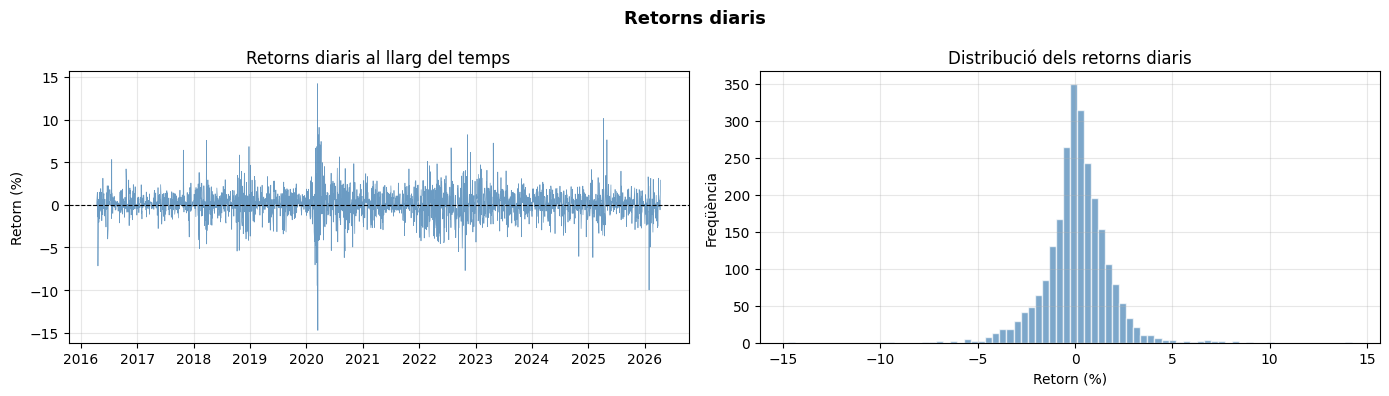

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Retorns diaris", fontsize=13, fontweight="bold")

axes[0].plot(df.index, df["Return"], color="steelblue", linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Retorns diaris al llarg del temps")
axes[0].set_ylabel("Retorn (%)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(df["Return"].dropna(), bins=80, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].set_title("Distribució dels retorns diaris")
axes[1].set_xlabel("Retorn (%)")
axes[1].set_ylabel("Freqüència")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Distribució per any

In [10]:
resum_anual = df.groupby(df.index.year).agg(
    Dies_mercat=("Close", "count"),
    Preu_inici=("Open", "first"),
    Preu_final=("Close", "last"),
    Preu_max=("High", "max"),
    Preu_min=("Low", "min"),
    Volum_mitja=("Volume", "mean"),
).round(2)

resum_anual["Retorn_any_%"] = ((resum_anual["Preu_final"] / resum_anual["Preu_inici"]) - 1).mul(100).round(2)
resum_anual

,Dies_mercat,Preu_inici,Preu_final,Preu_max,Preu_min,Volum_mitja,Retorn_any_%
Date,,,,,,,
2016,183,48.50,55.78,57.54,42.57,28767161.20,15.01
2017,251,56.36,78.49,80.29,55.61,22436169.72,39.27
2018,251,79.04,94.82,107.99,76.92,31590188.84,19.96
2019,252,92.93,149.39,151.14,90.74,24580994.05,60.76
2020,253,150.42,212.93,222.35,125.88,37659592.49,41.56
2021,252,213.04,324.68,337.56,202.90,26013012.70,52.40
2022,251,323.74,233.69,326.30,207.39,31219321.51,-27.82
2023,250,236.86,369.67,377.79,213.74,27677097.60,56.07
2024,252,367.53,417.46,462.10,360.29,20586623.02,13.59
